In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [114]:
df = pd.read_csv('train.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [115]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [116]:
df_dropped = df.drop(['PassengerId', 'Ticket', 'Name'], axis=1)
print(df_dropped.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S


In [117]:
df_filled = df_dropped.copy()
fill = {
    'Age': df_filled['Age'].mean(),
    'Embarked': df_filled['Embarked'].mode()[0]
}
df_filled = df_filled.fillna(fill)
print(df_filled.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      0
dtype: int64


In [118]:
df_filled['Age_20_35'] = df_filled['Age'].between(20, 35).astype(int)
df_filled['Age_35_50'] = df_filled['Age'].between(35, 50).astype(int)
df_filled['Age_50_80'] = df_filled['Age'].between(50, 80).astype(int)
print(df_filled[['Age_20_35', 'Age_35_50', 'Age_50_80']].sum())

Age_20_35    510
Age_35_50    171
Age_50_80     74
dtype: int64


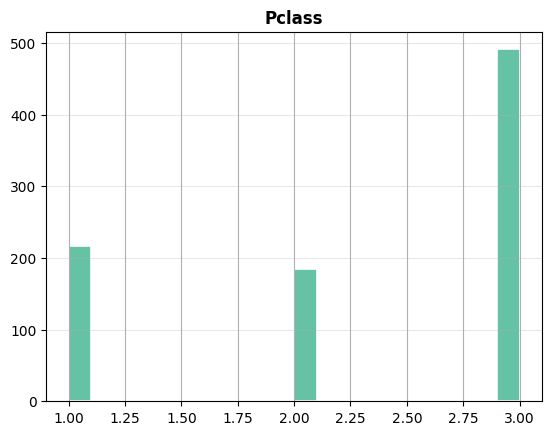

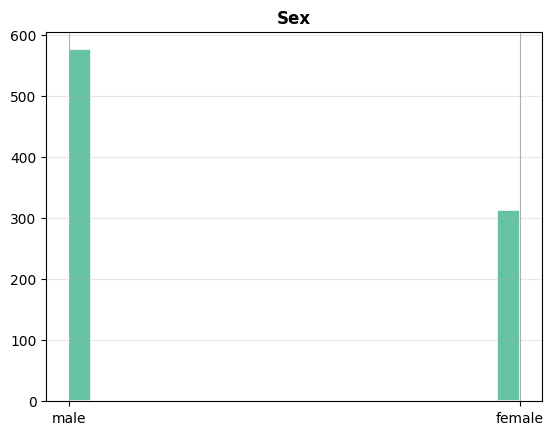

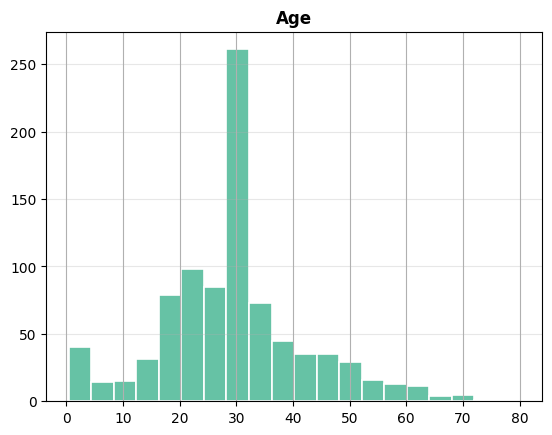

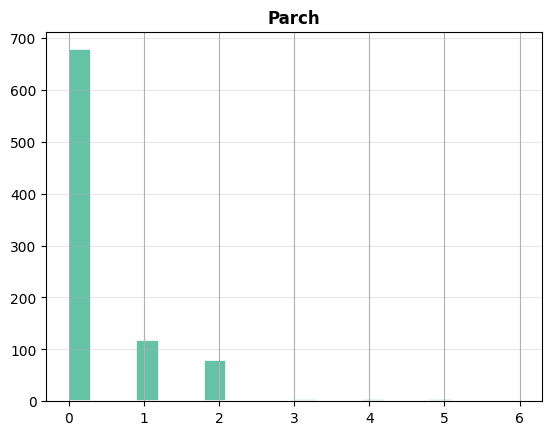

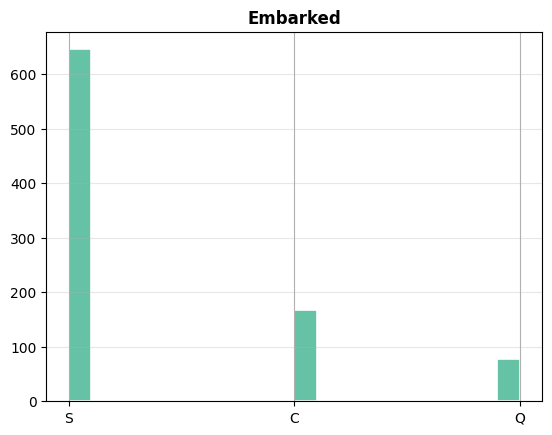

In [119]:
cols_to_plot = ['Pclass', 'Sex', 'Age', 'Parch', 'Embarked']
set2_colors = plt.cm.Set2.colors
pale_green = set2_colors[0]

for col in cols_to_plot:
    if col in df_filled.columns:
        plt.figure()
        df_filled[col].hist(bins=20, color=pale_green, edgecolor='white', linewidth=1.2)
        plt.title(f'{col}', fontsize=12, fontweight='bold')
        plt.grid(axis='y', alpha=0.3)
        plt.show()

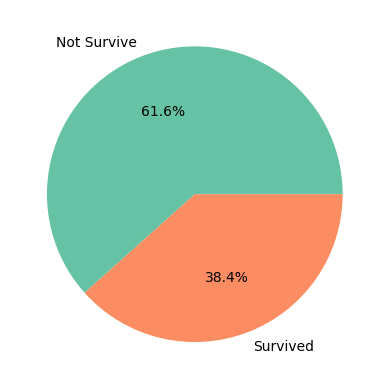

In [120]:
survived_counts = df_filled['Survived'].value_counts()
plt.figure()
colors = sns.color_palette("Set2")
plt.pie(survived_counts, labels=['Not Survive', 'Survived'], autopct='%1.1f%%', colors=colors)
plt.show()

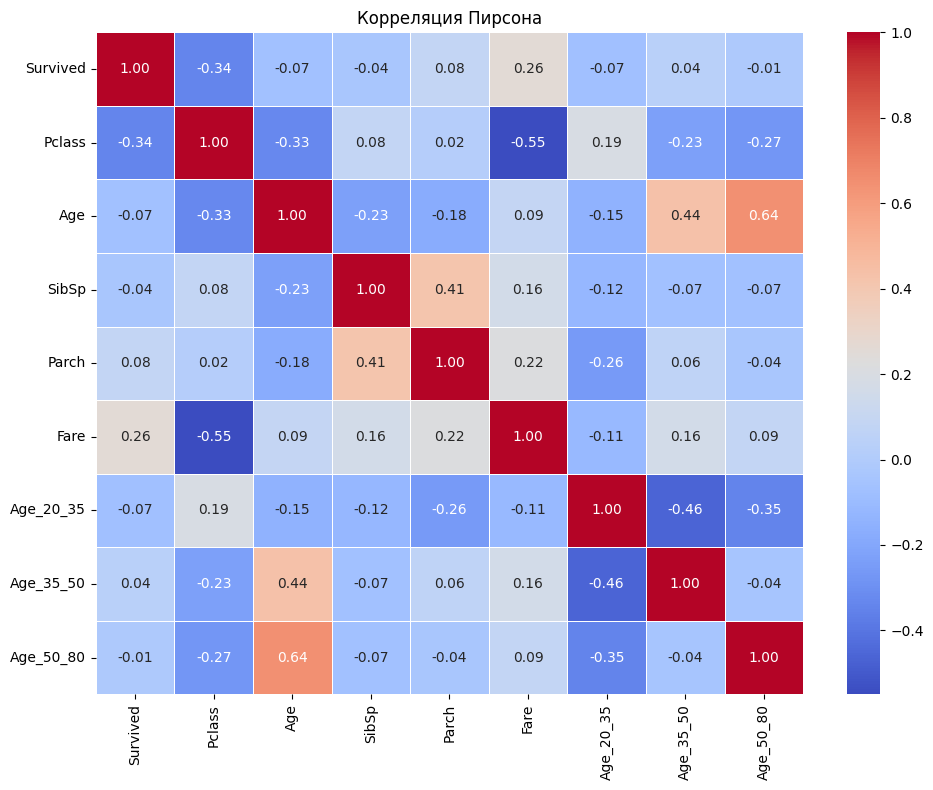

In [121]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_filled.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция Пирсона')
plt.tight_layout()
plt.show()

Благодаря корреляции Пирсона можно увидеть:  
Pclass (-0.34): пассажиры 1-го класса выживали чаще  
Fare (0.26): чем выше цена билета, тем выше шансы на выживание  
Age (-0.07): слабая отрицательная связь — дети выживали немного чаще  

In [122]:
print("Выживаемость по полу")
print(df_filled.groupby('Sex')['Survived'].mean().round(3))

print("\nВыживаемость по классу каюты")
print(df_filled.groupby('Pclass')['Survived'].mean().round(3))

Выживаемость по полу
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Выживаемость по классу каюты
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


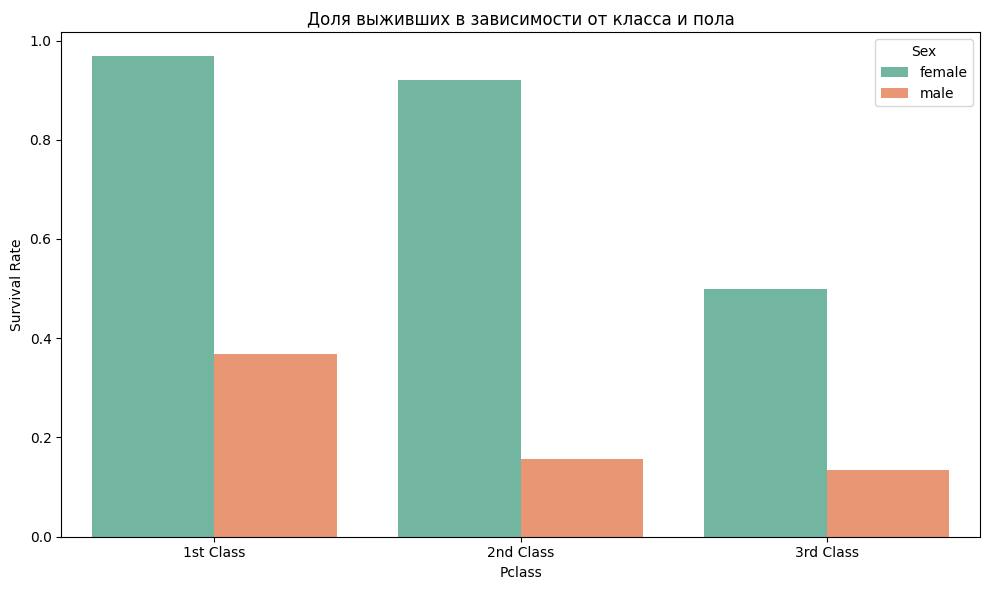

In [123]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_filled, x='Pclass', y='Survived', hue='Sex', errorbar=None, palette='Set2')
plt.title('Доля выживших в зависимости от класса и пола')
plt.ylabel('Survival Rate')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Sex')
plt.tight_layout()
plt.show()


Во всех классах кают доля выживших женщин выше доли выживших мужчин. Это подтверждается историческими фактами.  
Влияние социального класса:  
1-й и 2-й класс: женщины имели чрезвычайно высокие шансы на выживание.  
Мужчины 1-го класса выживали чаще, чем мужчины из других классов.  
3-й класс: самая низкая выживаемость, как у женщин, так и у мужчин.

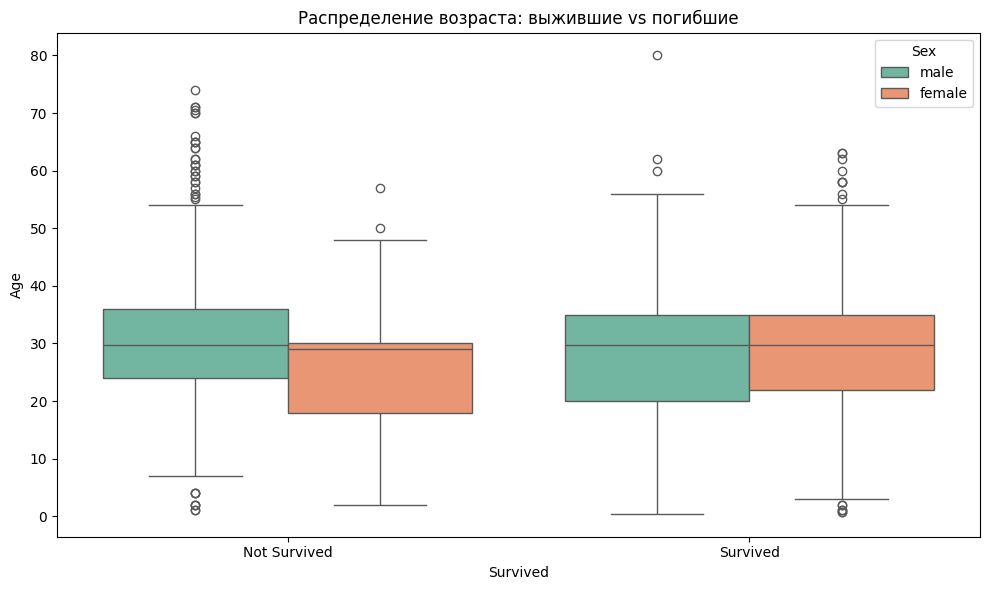

In [124]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filled, x='Survived', y='Age', hue='Sex', palette='Set2')
plt.title('Распределение возраста: выжившие vs погибшие')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

Not Survived:  
У мужчин средний возраст около 30 лет  
Женщины — около 25-28 лет  
Survived:  
Распределение аналогично Not Survived  
Выбросы показывают маленьких пассажиров и пожилых пассажиров

Добавляем новые признаки: наличие семьи или пассажир путешествует один. Также удаляем Cabin из-за количества пропусков.

In [125]:
df_ml = df_filled.copy()
df_ml['FamilySize'] = df_ml['SibSp'] + df_ml['Parch'] + 1

df_ml['IsAlone'] = (df_ml['FamilySize'] == 1).astype(int)
df_ml.drop('Cabin', axis=1, inplace=True)

print(df_ml.columns.tolist())
print(df_ml[['FamilySize', 'IsAlone']].head())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Age_20_35', 'Age_35_50', 'Age_50_80', 'FamilySize', 'IsAlone']
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


In [126]:
df_encoded = pd.get_dummies(df_ml, columns=['Sex', 'Embarked'], drop_first=True)

X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")

Размер train: (712, 13)
Размер test: (179, 13)


                  precision    recall  f1-score   support

Not Survived (0)       0.80      0.88      0.84       110
    Survived (1)       0.78      0.65      0.71        69

        accuracy                           0.79       179
       macro avg       0.79      0.77      0.77       179
    weighted avg       0.79      0.79      0.79       179

Accuracy: 0.7933


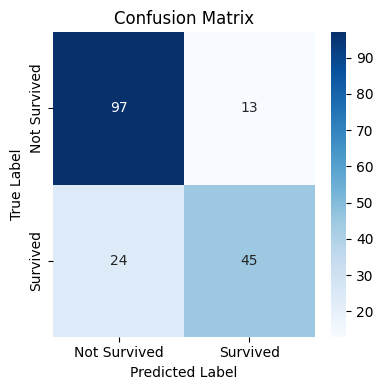

In [127]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Not Survived (0)', 'Survived (1)']))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


plt.figure(figsize=(4, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()